In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
# Load iris dataset
iris = load_iris()
X, y = iris.data, iris.target

In [3]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [5]:
# Convert to torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

In [11]:
# Defining simple NN model
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 10)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(10, 3)  # 3 output classes

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x  # raw logits, CrossEntropyLoss applies softmax internally

model = IrisClassifier()

In [12]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [13]:
# Training loop
epochs = 100
train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Evaluate on test set
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test)
        test_losses.append(test_loss.item())
    
    if (epoch+1) % 10 == 0:
        _, predicted = torch.max(test_outputs, 1)
        acc = accuracy_score(y_test, predicted)
        print(f"Epoch {epoch+1}, Train loss: {loss.item():.4f}, Test loss: {test_loss.item():.4f}, Test accuracy: {acc:.4f}")
    


Epoch 10, Train loss: 0.9137, Test loss: 0.8877, Test accuracy: 0.6333
Epoch 20, Train loss: 0.5933, Test loss: 0.5873, Test accuracy: 0.8000
Epoch 30, Train loss: 0.4119, Test loss: 0.4351, Test accuracy: 0.8000
Epoch 40, Train loss: 0.3223, Test loss: 0.3530, Test accuracy: 0.8333
Epoch 50, Train loss: 0.2601, Test loss: 0.2916, Test accuracy: 0.9333
Epoch 60, Train loss: 0.2104, Test loss: 0.2422, Test accuracy: 0.9667
Epoch 70, Train loss: 0.1694, Test loss: 0.1999, Test accuracy: 0.9667
Epoch 80, Train loss: 0.1370, Test loss: 0.1648, Test accuracy: 0.9667
Epoch 90, Train loss: 0.1138, Test loss: 0.1396, Test accuracy: 0.9667
Epoch 100, Train loss: 0.0970, Test loss: 0.1218, Test accuracy: 0.9667


Final Test Accuracy: 96.67%


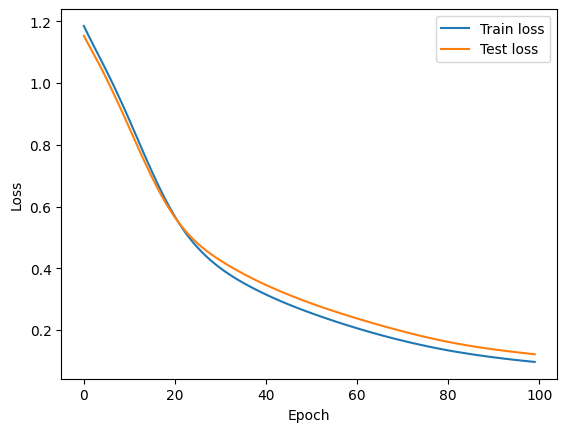

In [14]:
# Final accuracy
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)
    final_acc = accuracy_score(y_test, predicted)

print(f"Final Test Accuracy: {final_acc*100:.2f}%")

# Plot train/test loss
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()